In [1]:
list.of.packages <- c("tidyverse","fixest","stargazer","ggfixest","patchwork","ggpubr","data.table")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 



Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


Les objets suivan

In [2]:
T_bins_labels <- c("<=17°C","17,21]","21,23]","23,25]","25,27]","27,29]","29,31]","31,33]",">33°C")
T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")
T_bins_labels_pretty_wo_ref <- c("≤17°C", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")

bin_ref_T <-"17,21]"

In [3]:
varT <- "T_i30_bin"
varT_permut <- "T_i30_bin_permut"

dict_levels_T <- setNames(paste0("T: ",T_bins_labels_pretty), paste0(varT, "::", T_bins_labels))
dict_levels_T_perm <- setNames(paste0("T permut: ",T_bins_labels_pretty), paste0(varT_permut, "::", T_bins_labels))

dict <- c(dict_levels_T, dict_levels_T_perm)

# Women

In [4]:
df_women <- fread("./2_Regression_datasets/output/df_reg_women.csv")
sprintf("%i rows x %i columns", nrow(df_women), ncol(df_women))
head(df_women,2)

[1] "973462 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Women_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Currently_pregnant,Blood_hemo_level_alti,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Body_mass_index,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Women_anemia,Women_severe_anemia,Women_moderate_anemia,Women_mild_anemia,Women_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T

In [5]:
df_reg_women <- df_women %>%
                    mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels)
)

# Actual model

In [6]:
reg_women <- feols(Blood_hemo_level_alti ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 +
                                        Current_age + N_year_educ + 
                                        Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                        vcov = ~District_ID,
                    df_reg_women)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



In [7]:
actual_coefs <- coef(reg_women)[1:8]
actual_coefs

T_i30_bin::<=17°C T_i30_bin::21,23] T_i30_bin::23,25] T_i30_bin::25,27] 
      -0.05189095       -0.64319018       -1.46994192       -2.44589472 
T_i30_bin::27,29] T_i30_bin::29,31] T_i30_bin::31,33]  T_i30_bin::>33°C 
      -3.17189690       -3.68403239       -3.53524898       -3.57246502

In [8]:
actual_se <- se(reg_women)[1:8]
actual_se

T_i30_bin::<=17°C T_i30_bin::21,23] T_i30_bin::23,25] T_i30_bin::25,27] 
        0.2639516         0.2084541         0.3259866         0.4072814 
T_i30_bin::27,29] T_i30_bin::29,31] T_i30_bin::31,33]  T_i30_bin::>33°C 
        0.4593337         0.4920000         0.5192804         0.6254533

# Randomized temperature exposure

In [9]:
# Ensure reproducibility
set.seed(123)

In [10]:
thresholds_T <- c(-17,17,21,23,25,27,29,31,33,40)

In [11]:
df_reg_women_rand <- df_women %>%
                select(Blood_hemo_level_alti,T_i30,P_tot_30,
                       Current_age,N_year_educ,
                       Smoker,Health_insurance, 
                       Religion_muslim,Religion_not_hindu_nor_muslim, 
                       Ethni_SC,Ethni_ST,Ethni_OBC,
                       Wealth_lowest,Wealth_second,Wealth_fourth,Wealth_highest,
                       Urban,
                       District_ID,Measured_month,Measured_year)%>%
                mutate(T_i30_permut = sample(T_i30),
                       T_i30_bin_permut = cut(T_i30_permut, breaks = thresholds_T, 
                                           labels = T_bins_labels,
                                           include.lowest = TRUE),
                       T_i30_bin_permut=factor(T_i30_bin_permut,levels = T_bins_labels))
sprintf("%i rows x %i columns", nrow(df_reg_women_rand), ncol(df_reg_women_rand))
head(df_reg_women_rand,2)

[1] "973462 rows x 22 columns"

Blood_hemo_level_alti,T_i30,P_tot_30,Current_age,N_year_educ,Smoker,Health_insurance,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Wealth_lowest,Wealth_second,Wealth_fourth,Wealth_highest,Urban,District_ID,Measured_month,Measured_year,T_i30_permut,T_i30_bin_permut
<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<dbl>,<fct>
81,26.94861,0.2628756,46,0,1,0,0,1,0,0,0,0,0,0,0,1,Andaman & Nicobar Island_South Andaman,7,2015,26.238889,"25,27]"
113,26.94861,0.2628756,20,14,0,0,0,1,0,0,0,0,0,0,0,1,Andaman & Nicobar Island_South Andaman,7,2015,6.376389,<=17°C


# Regression with randomized temperature

In [12]:
reg_women_rand <- feols(Blood_hemo_level_alti ~ i(T_i30_bin_permut,ref=bin_ref_T)  + P_tot_30 +
                                        Current_age + N_year_educ + 
                                        Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                       |District_ID^Measured_month + District_ID^Measured_year,
                        vcov = ~District_ID,
                        df_reg_women_rand)

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).



# Compare actual and randomized models

In [13]:
etable(reg_women,reg_women_rand,
       tex=TRUE,
       fitstat = ~ n + r2 + my,
       drop="%!_bin",
       dict=dict)

\begingroup
\centering
\begin{tabular}{lcc}
   \tabularnewline \midrule \midrule
   Dependent Variable: & \multicolumn{2}{c}{Blood\_hemo\_level\_alti}\\
   Model:                         & (1)             & (2)\\  
   \midrule
   \emph{Variables}\\
   T: ≤17°C                       & -0.0519         &   \\   
                                  & (0.2640)        &   \\   
   T: (21,23]                     & -0.6432$^{***}$ &   \\   
                                  & (0.2085)        &   \\   
   T: (23,25]                     & -1.470$^{***}$  &   \\   
                                  & (0.3260)        &   \\   
   T: (25,27]                     & -2.446$^{***}$  &   \\   
                                  & (0.4073)        &   \\   
   T: (27,29]                     & -3.172$^{***}$  &   \\   
                                  & (0.4593)        &   \\   
   T: (29,31]                     & -3.684$^{***}$  &   \\   
                                  & (0.4920)        &   \\   
   T: (

# Permutations

In [14]:
# Number of permutations
num_permutations <- 100

In [15]:
# Initialize a matrix to store the coefficients from each permutation
coefficients_matrix <- matrix(NA, nrow = num_permutations, ncol = length(actual_coefs))

In [16]:
colnames(coefficients_matrix) <- names(actual_coefs)

In [17]:
for (i in 1:num_permutations) {
            df_permuted <- df_women %>%
                        select(Blood_hemo_level_alti,T_i30,P_tot_30,
                               Current_age,N_year_educ,
                               Smoker,Health_insurance, 
                               Religion_muslim,Religion_not_hindu_nor_muslim, 
                               Ethni_SC,Ethni_ST,Ethni_OBC,
                               Wealth_lowest,Wealth_second,Wealth_fourth,Wealth_highest,
                               Urban,
                               District_ID,Measured_month,Measured_year)%>%
                        mutate(T_i30 = sample(T_i30),
                               T_i30_bin = cut(T_i30, breaks = thresholds_T, 
                                                   labels = T_bins_labels,
                                                   include.lowest = TRUE),
                               T_i30_bin=factor(T_i30_bin,levels = T_bins_labels))
            # Fit the model with permuted temperature bins
            reg <- feols(Blood_hemo_level_alti ~ i(T_i30_bin,ref=bin_ref_T)  + P_tot_30 +
                                        Current_age + N_year_educ + 
                                        Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban 
                                        |District_ID^Measured_month + District_ID^Measured_year,
                        vcov = ~District_ID,
                        df_permuted)
            # Store the coefficients of the permuted temperature bins
            coefficients_matrix[i, ] <- coef(reg)[1:8]
    }

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 59,850 observations removed because of NA values (RHS: 59,850).
       17/1 fixed-effect singletons were removed (17 observations).

NOTES: 59,850 observ

## Summarize permutation coefficients

In [18]:
coefficients_summary <- apply(coefficients_matrix, 2, function(x) c(mean = mean(x), sd = sd(x)))
coefficients_summary

,T_i30_bin::<=17°C,"T_i30_bin::21,23]","T_i30_bin::23,25]","T_i30_bin::25,27]","T_i30_bin::27,29]","T_i30_bin::29,31]","T_i30_bin::31,33]",T_i30_bin::>33°C
mean,-0.003071271,-0.000525699,0.002542288,-0.002220165,0.003424965,-0.005130385,0.005778202,-0.0006685596
sd,0.069809475,0.072503878,0.076748105,0.060851502,0.056605598,0.068516235,0.096105634,0.0992856830


# Plot

In [19]:
# Prepare data for plotting
plot_data <- data.frame(Names = factor(T_bins_labels_pretty_wo_ref,
                                       levels=T_bins_labels_pretty_wo_ref),
                        Actual = actual_coefs,
                        Actual_SD = actual_se,
                        Permuted_Mean = coefficients_summary[1, ],
                        Permuted_SD = coefficients_summary[2, ]
                        )
plot_data

,Names,Actual,Actual_SD,Permuted_Mean,Permuted_SD
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T_i30_bin::<=17°C,≤17°C,-0.05189095,0.2639516,-0.0030712707,0.06980947
"T_i30_bin::21,23]","(21,23]",-0.64319018,0.2084541,-0.0005256990,0.07250388
"T_i30_bin::23,25]","(23,25]",-1.46994192,0.3259866,0.0025422885,0.07674810
"T_i30_bin::25,27]","(25,27]",-2.44589472,0.4072814,-0.0022201650,0.06085150
"T_i30_bin::27,29]","(27,29]",-3.17189690,0.4593337,0.0034249651,0.05660560
"T_i30_bin::29,31]","(29,31]",-3.68403239,0.4920000,-0.0051303851,0.06851624
"T_i30_bin::31,33]","(31,33]",-3.53524898,0.5192804,0.0057782016,0.09610563
T_i30_bin::>33°C,>33°C,-3.57246502,0.6254533,-0.0006685596,0.09928568


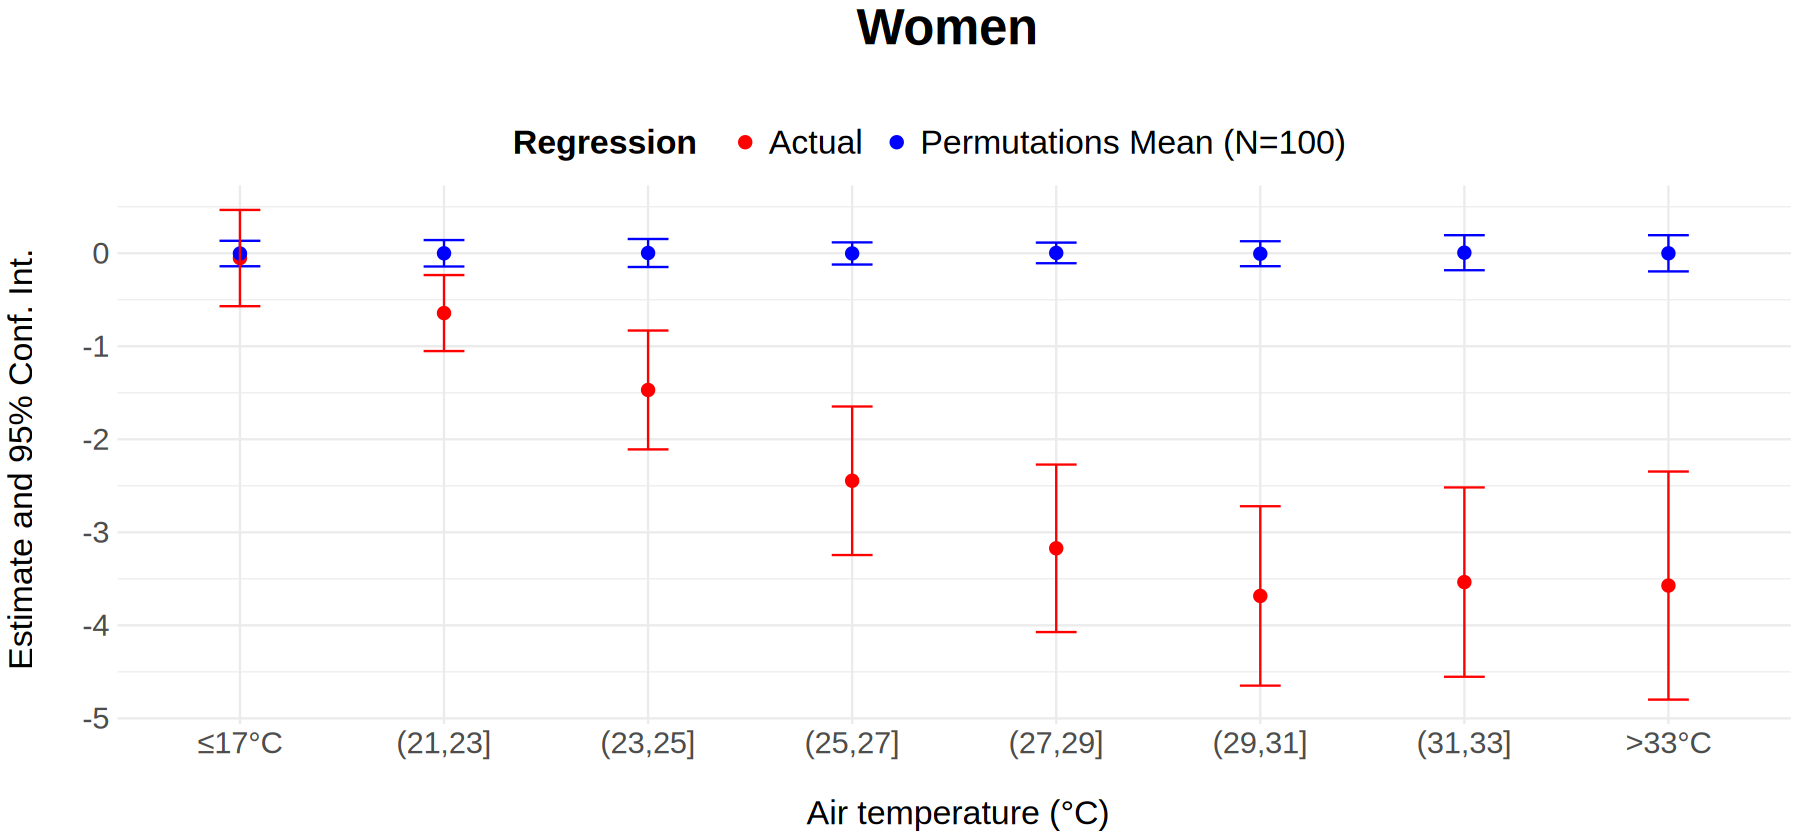

In [20]:
options(repr.plot.width=15, repr.plot.height=7, scipen=9999)

plot <- ggplot(plot_data, aes(x = Names)) +
              geom_point(aes(y = Actual,color="Actual"), size = 3) +
              geom_point(aes(y = Permuted_Mean,color="Permutations Mean (N=100)"), size = 3) +
              geom_errorbar(aes(ymin = Permuted_Mean - 1.96 * Permuted_SD, 
                                ymax = Permuted_Mean + 1.96 * Permuted_SD), 
                                width = 0.2,color="blue") +
              geom_errorbar(aes(ymin = Actual - 1.96 * Actual_SD, 
                                ymax = Actual + 1.96 * Actual_SD), 
                                width = 0.2,color="red") + 
              scale_color_manual(values = c('red','blue'))+              
              labs(#title = "Comparison of Actual and Permutation Test Coefficients \n",
                   title = "Women \n",
                   x = "\n Air temperature (°C)",
                   y = "Estimate and 95% Conf. Int. \n",
                   color = "Regression"
                   ) +
              theme_minimal()+
              theme(plot.title = element_text(size = 30, face="bold", hjust=0.5),
                    legend.position="top",
                    legend.title = element_text(size = 20,face ="bold"),
                    legend.text = element_text(size = 20),
                    axis.text.x = element_text(size = 18),
                    axis.text.y = element_text(size = 18),
                    axis.title.x = element_text(size = 20, hjust = 0.5),
                    axis.title.y = element_text(size = 20, hjust = 0.5)
                        )
plot

In [21]:
ggsave("./3_output/img/falsification_women.png", width=15, height=7, plot)